# EDA — AREASS Synthetic Data Pipeline
**Kelompok 2 — IF5200 Perancangan Penelitian Terapan**

Notebook ini memvalidasi pipeline `datagen.py → preprocessing.py` secara end-to-end,
mulai dari generasi data sintetis hingga feature matrix yang siap dipakai model.

Struktur:
1. Setup & Generasi Data
2. EDA Raw Data (output datagen.py)
3. Pipeline Preprocessing (preprocessing.py)
4. EDA Engineered Features
5. Validasi Train-Test Split
6. EDA Post-Scaling
7. Sanity Check Inference Preprocessing (inference.py)

---
## 1. Setup & Generasi Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os, sys, pickle

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Tambahkan direktori script ke path agar import berjalan
SCRIPT_DIR = os.path.abspath('.')   # sesuaikan jika perlu
sys.path.insert(0, SCRIPT_DIR)

SEED        = 42
N_STUDENTS  = 3000
DATA_PATH   = '/tmp/areass_raw.csv'
ARTIFACT_DIR = '/tmp/areass_artifacts'

LABEL_ORDER  = ['lulus_tepat_waktu', 'lulus_terlambat', 'dropout']
LABEL_COLORS = {'lulus_tepat_waktu': '#4CAF50', 'lulus_terlambat': '#FF9800', 'dropout': '#F44336'}

print('Setup selesai.')

Setup selesai.


In [2]:
from datagen import generate_data_sintetis

df_raw = generate_data_sintetis(
    n_students=N_STUDENTS,
    strata_distribution={'S1': 0.7, 'S2': 0.2, 'S3': 0.1},
    random_seed=685685684645625668679789,
)
df_raw.to_csv(DATA_PATH, index=False)

print(f'Total baris  : {len(df_raw):,}')
print(f'Total mahasiswa: {df_raw["student_id"].nunique():,}')
print(f'Kolom        : {list(df_raw.columns)}')

Total baris  : 22,526
Total mahasiswa: 3,000
Kolom        : ['student_id', 'strata', 'semester', 'ip_semester', 'ipk_total', 'sks_semester', 'total_sks', 'sks_lulus', 'sks_tidak_lulus', 'label_kelulusan']


In [5]:
df_raw = pd.read_csv("./data/v2.csv")
print(f'Total baris  : {len(df_raw):,}')

Total baris  : 20,579


---
## 2. EDA Raw Data

### 2.1 Ringkasan Skema & Missing Values

In [3]:
df_raw["label_kelulusan"].value_counts()

label_kelulusan
lulus_tepat_waktu    10706
lulus_terlambat       8376
dropout               3058
Name: count, dtype: int64

In [4]:
print('=== dtypes & non-null count ===')
print(df_raw.info())
print('\n=== Descriptive statistics ===')
df_raw.describe(include='all').T

=== dtypes & non-null count ===
<class 'pandas.DataFrame'>
RangeIndex: 20348 entries, 0 to 20347
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       20348 non-null  int64  
 1   strata           20348 non-null  str    
 2   semester         20348 non-null  int64  
 3   ip_semester      20348 non-null  float64
 4   ipk_total        20348 non-null  float64
 5   sks_semester     20348 non-null  int64  
 6   total_sks        20348 non-null  int64  
 7   sks_lulus        20348 non-null  int64  
 8   sks_tidak_lulus  20348 non-null  int64  
 9   label_kelulusan  20348 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.6 MB
None

=== Descriptive statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,20348.0,NaN,NaN,NaN,1491.085905,866.941549,1.0,739.0,1491.0,2229.0,3000.0
strata,20348,3,S1,17962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
semester,20348.0,NaN,NaN,NaN,4.575241,2.725114,1.0,2.0,4.0,7.0,13.0
ip_semester,20348.0,NaN,NaN,NaN,2.715448,0.576634,0.73,2.32,2.723,3.122,4.0
ipk_total,20348.0,NaN,NaN,NaN,2.707989,0.522435,0.91,2.35,2.705,3.08,4.0
sks_semester,20348.0,NaN,NaN,NaN,19.432524,2.567689,15.0,18.0,19.0,21.0,24.0
total_sks,20348.0,NaN,NaN,NaN,87.869815,50.086655,18.0,42.0,84.0,131.0,216.0
sks_lulus,20348.0,NaN,NaN,NaN,78.673678,44.554221,12.0,39.0,75.0,118.0,167.0
sks_tidak_lulus,20348.0,NaN,NaN,NaN,9.196137,9.330296,0.0,3.0,6.0,12.0,63.0
label_kelulusan,20348,3,lulus_tepat_waktu,9197,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Missing values check
missing = df_raw.isnull().sum()
print('Missing values per kolom:')
print(missing[missing > 0] if missing.any() else '  ✓ Tidak ada missing values.')

Missing values per kolom:
  ✓ Tidak ada missing values.


### 2.2 Distribusi Label Kelulusan

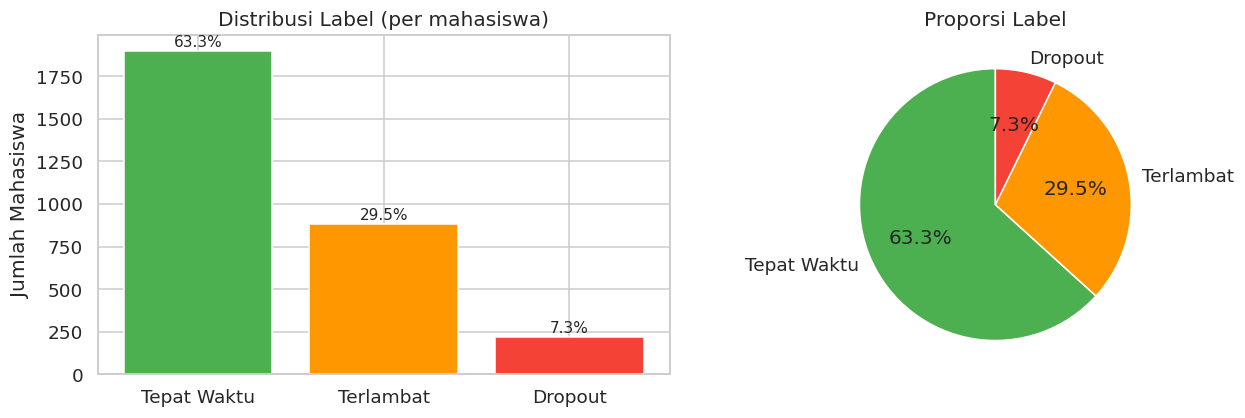

Class imbalance ratio (majority/minority): 8.71


In [3]:
# Per-mahasiswa (bukan per-baris)
df_student = df_raw.drop_duplicates('student_id').copy()

label_counts = df_student['label_kelulusan'].value_counts().reindex(LABEL_ORDER)
label_pct    = label_counts / label_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(LABEL_ORDER, label_counts,
                   color=[LABEL_COLORS[l] for l in LABEL_ORDER], edgecolor='white')
for bar, pct in zip(bars, label_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Distribusi Label (per mahasiswa)')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Tepat Waktu', 'Terlambat', 'Dropout'], rotation=0)

# Pie chart
axes[1].pie(label_counts, labels=['Tepat Waktu', 'Terlambat', 'Dropout'],
            colors=[LABEL_COLORS[l] for l in LABEL_ORDER],
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporsi Label')

plt.tight_layout()
plt.show()

print('Class imbalance ratio (majority/minority):', round(label_counts.max()/label_counts.min(), 2))

### 2.3 Distribusi per Strata

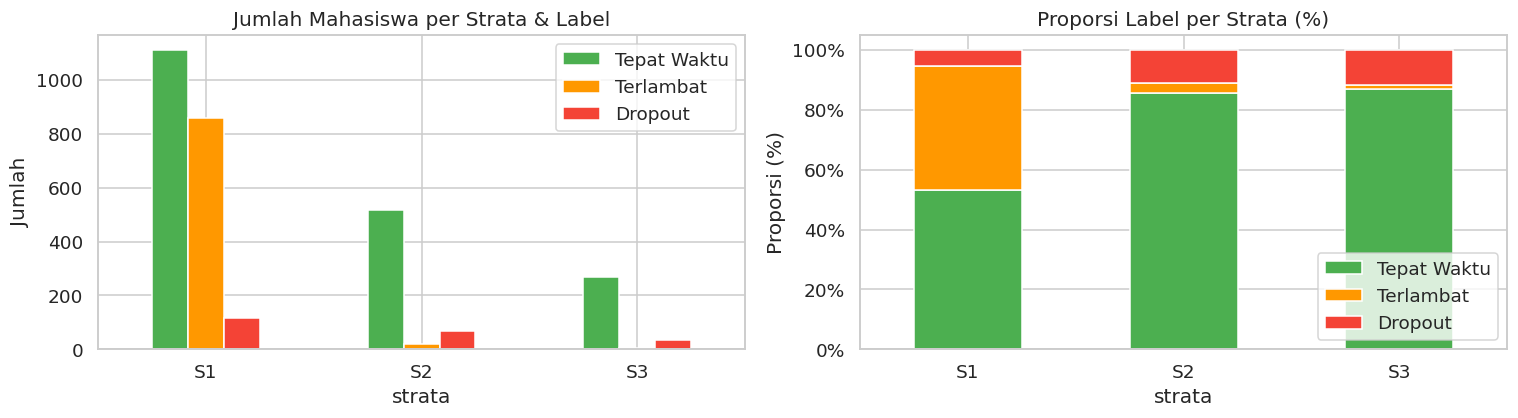

label_kelulusan  lulus_tepat_waktu  lulus_terlambat  dropout
strata                                                      
S1                            53.3             41.2      5.5
S2                            85.5              3.5     11.1
S3                            86.7              1.6     11.7


In [4]:
strata_label = df_student.groupby(['strata', 'label_kelulusan']).size().unstack(fill_value=0)
strata_label = strata_label.reindex(columns=LABEL_ORDER)
strata_label_pct = strata_label.div(strata_label.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

strata_label.plot(kind='bar', ax=axes[0],
                  color=[LABEL_COLORS[l] for l in LABEL_ORDER],
                  edgecolor='white', rot=0)
axes[0].set_title('Jumlah Mahasiswa per Strata & Label')
axes[0].set_ylabel('Jumlah')
axes[0].legend(['Tepat Waktu', 'Terlambat', 'Dropout'], loc='upper right')

strata_label_pct.plot(kind='bar', stacked=True, ax=axes[1],
                      color=[LABEL_COLORS[l] for l in LABEL_ORDER],
                      edgecolor='white', rot=0)
axes[1].set_title('Proporsi Label per Strata (%)')
axes[1].set_ylabel('Proporsi (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(['Tepat Waktu', 'Terlambat', 'Dropout'], loc='lower right')

plt.tight_layout()
plt.show()

print(strata_label_pct.round(1))

### 2.4 Distribusi Jumlah Semester per Mahasiswa

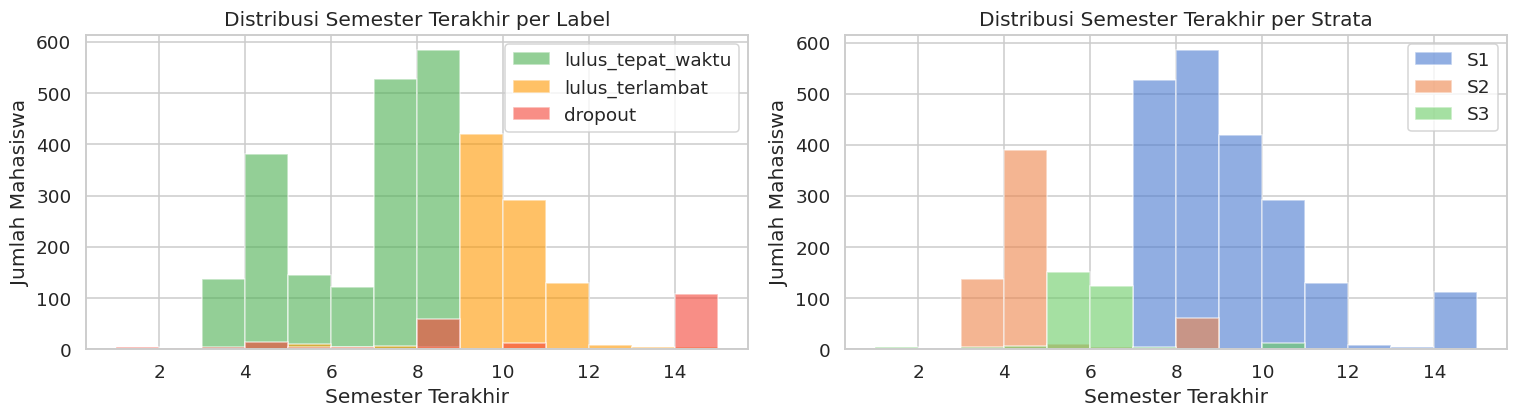

In [5]:
sem_per_student = df_raw.groupby('student_id')['semester'].max().reset_index()
sem_per_student = sem_per_student.merge(df_student[['student_id','strata','label_kelulusan']], on='student_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label in LABEL_ORDER:
    subset = sem_per_student[sem_per_student['label_kelulusan'] == label]
    axes[0].hist(subset['semester'], bins=range(1, 16), alpha=0.6,
                 label=label, color=LABEL_COLORS[label], edgecolor='white')
axes[0].set_title('Distribusi Semester Terakhir per Label')
axes[0].set_xlabel('Semester Terakhir')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].legend()

for strata in ['S1', 'S2', 'S3']:
    subset = sem_per_student[sem_per_student['strata'] == strata]
    axes[1].hist(subset['semester'], bins=range(1, 16), alpha=0.6, label=strata, edgecolor='white')
axes[1].set_title('Distribusi Semester Terakhir per Strata')
axes[1].set_xlabel('Semester Terakhir')
axes[1].set_ylabel('Jumlah Mahasiswa')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.5 Distribusi IP Semester & IPK Total

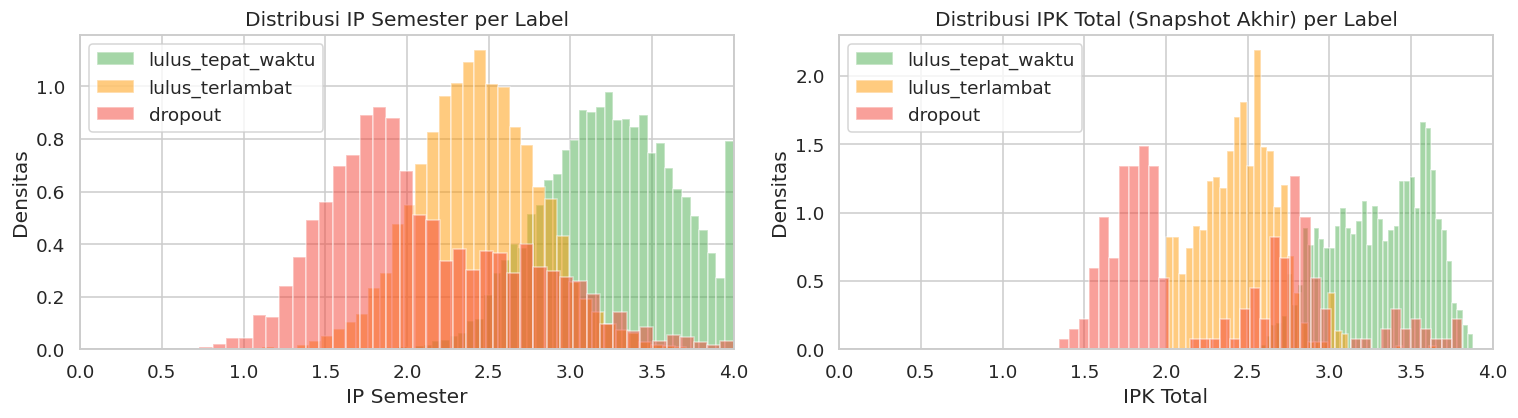

=== IPK Total (snapshot akhir) per label ===
                    mean    std    min    max
label_kelulusan                              
dropout            2.283  0.613  1.343  3.810
lulus_tepat_waktu  3.300  0.298  2.578  3.882
lulus_terlambat    2.460  0.236  2.000  3.653


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label in LABEL_ORDER:
    subset = df_raw[df_raw['label_kelulusan'] == label]
    axes[0].hist(subset['ip_semester'], bins=40, alpha=0.5,
                 label=label, color=LABEL_COLORS[label], density=True, edgecolor='white')
axes[0].set_title('Distribusi IP Semester per Label')
axes[0].set_xlabel('IP Semester')
axes[0].set_ylabel('Densitas')
axes[0].legend()
axes[0].set_xlim(0, 4)

# IPK per semester terakhir (snapshot akhir)
df_last = df_raw.sort_values('semester').groupby('student_id').last().reset_index()
for label in LABEL_ORDER:
    subset = df_last[df_last['label_kelulusan'] == label]
    axes[1].hist(subset['ipk_total'], bins=40, alpha=0.5,
                 label=label, color=LABEL_COLORS[label], density=True, edgecolor='white')
axes[1].set_title('Distribusi IPK Total (Snapshot Akhir) per Label')
axes[1].set_xlabel('IPK Total')
axes[1].set_ylabel('Densitas')
axes[1].legend()
axes[1].set_xlim(0, 4)

plt.tight_layout()
plt.show()

# Statistik per label
print('=== IPK Total (snapshot akhir) per label ===')
print(df_last.groupby('label_kelulusan')['ipk_total'].agg(['mean','std','min','max']).round(3))

In [15]:
# filter by dropout and S1
df_last[(df_last['label_kelulusan'] != 'dropout') & (df_last['strata'] == 'S2') & (df_last['ipk_total'] < 3.0) ]

,student_id,strata,semester,ip_semester,ipk_total,sks_semester,total_sks,sks_lulus,sks_tidak_lulus,label_kelulusan


### 2.6 Distribusi SKS

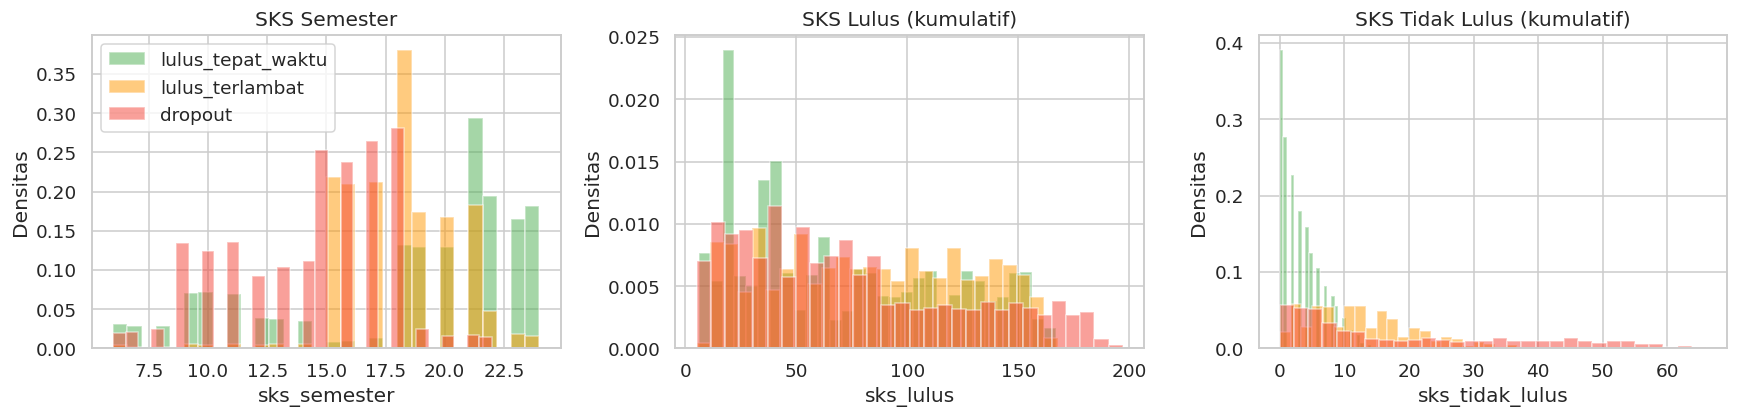

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes,
    ['sks_semester', 'sks_lulus', 'sks_tidak_lulus'],
    ['SKS Semester', 'SKS Lulus (kumulatif)', 'SKS Tidak Lulus (kumulatif)']):
    for label in LABEL_ORDER:
        subset = df_raw[df_raw['label_kelulusan'] == label]
        ax.hist(subset[col], bins=30, alpha=0.5, label=label,
                color=LABEL_COLORS[label], density=True, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Densitas')

axes[0].legend()
plt.tight_layout()
plt.show()

### 2.7 Validasi Konsistensi Internal Raw Data

Cek constraint fisik yang harus selalu terpenuhi dari datagen.

In [9]:
errors = []

# IP harus [0,4]
if not ((df_raw['ip_semester'] >= 0) & (df_raw['ip_semester'] <= 4)).all():
    errors.append('ip_semester di luar [0, 4]')
if not ((df_raw['ipk_total'] >= 0) & (df_raw['ipk_total'] <= 4)).all():
    errors.append('ipk_total di luar [0, 4]')

# SKS tidak negatif
for col in ['sks_semester', 'sks_lulus', 'sks_tidak_lulus', 'total_sks']:
    if (df_raw[col] < 0).any():
        errors.append(f'{col} mengandung nilai negatif')

# sks_lulus <= total_sks
if not (df_raw['sks_lulus'] <= df_raw['total_sks']).all():
    errors.append('sks_lulus > total_sks ditemukan')

# sks_lulus + sks_tidak_lulus ≈ total_sks (kumulatif)
# Catatan: total_sks adalah kumulatif sks_semester, sks_lulus & sks_tidak_lulus juga kumulatif
diff = (df_raw['sks_lulus'] + df_raw['sks_tidak_lulus'] - df_raw['total_sks']).abs()
if diff.max() > 1:  # toleransi 1 karena pembulatan
    errors.append(f'sks_lulus + sks_tidak_lulus ≠ total_sks (max diff={diff.max()})')

# Label hanya dari nilai valid
valid_labels = {'lulus_tepat_waktu', 'lulus_terlambat', 'dropout'}
unknown = set(df_raw['label_kelulusan'].unique()) - valid_labels
if unknown:
    errors.append(f'Label tidak dikenal: {unknown}')

# Semester harus positif dan terurut per mahasiswa
sem_check = df_raw.groupby('student_id')['semester'].apply(
    lambda s: list(s) == list(range(1, len(s)+1))
)
if not sem_check.all():
    errors.append(f'{(~sem_check).sum()} mahasiswa memiliki urutan semester tidak kontinu')

# Satu label per mahasiswa
multi_label = df_raw.groupby('student_id')['label_kelulusan'].nunique()
if (multi_label > 1).any():
    errors.append(f'{(multi_label > 1).sum()} mahasiswa memiliki lebih dari 1 label')

print('=== Validasi Konsistensi Raw Data ===')
if errors:
    for e in errors:
        print(f'  ✗ {e}')
else:
    print('  ✓ Semua constraint terpenuhi.')

=== Validasi Konsistensi Raw Data ===
  ✓ Semua constraint terpenuhi.


### 2.8 Tren IP per Label (rata-rata per semester)

In [ ]:
# Rata-rata IP per nomor semester, per label
ip_trend = df_raw.groupby(['label_kelulusan', 'semester'])['ip_semester'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
for label in LABEL_ORDER:
    subset = ip_trend[ip_trend['label_kelulusan'] == label]
    ax.plot(subset['semester'], subset['ip_semester'],
            marker='o', label=label, color=LABEL_COLORS[label])
ax.set_title('Rata-rata IP Semester per Nomor Semester & Label')
ax.set_xlabel('Nomor Semester')
ax.set_ylabel('Rata-rata IP Semester')
ax.set_xticks(range(1, 15))
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Pipeline Preprocessing

Jalankan seluruh pipeline `preprocessing.py` dan tangkap output tiap step.

In [ ]:
from preprocessing import (
    load_and_validate, engineer_features, encode, select_columns,
    split_data, scale_features, save_artifacts,
    FEATURE_COLUMNS, FEATURES_TO_SCALE, LABEL_ENCODING, STRATA_ENCODING, TARGET_COLUMN
)

# Step 1
df_validated = load_and_validate(DATA_PATH)
print(f'Shape setelah load: {df_validated.shape}')

In [ ]:
# Step 2 — Feature engineering
df_engineered = engineer_features(df_validated)
new_features = ['rasio_sks_lulus', 'rata_sks_gagal_per_sem', 'rasio_progress', 'ip_trend', 'ip_std']
print('Kolom baru:', new_features)
print(df_engineered[new_features].describe().round(4))

In [ ]:
# Step 3 — Encoding
df_encoded = encode(df_engineered)
print('strata unique values:', sorted(df_encoded['strata'].unique()))
print('label_encoded unique values:', sorted(df_encoded['label_encoded'].unique()))

In [ ]:
# Step 4 — Select columns
df_selected = select_columns(df_encoded)
print('Kolom setelah select:', list(df_selected.columns))
print('Shape:', df_selected.shape)

In [ ]:
# Step 5 — Split
X_train, X_test, y_train, y_test = split_data(df_selected, test_size=0.2, random_state=SEED)

In [ ]:
# Step 6 — Scaling
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# Step 7 — Save artifacts
save_artifacts(X_train_scaled, X_test_scaled, y_train, y_test, scaler, ARTIFACT_DIR)

---
## 4. EDA Engineered Features

### 4.1 Distribusi Feature Baru (snapshot semester terakhir)

In [ ]:
# Gunakan df_engineered sebelum encoding, ambil snapshot terakhir per mahasiswa
df_snap = df_engineered.sort_values('semester').groupby('student_id').last().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

feat_configs = [
    ('rasio_sks_lulus',       'Rasio SKS Lulus'),
    ('rata_sks_gagal_per_sem','Rata SKS Gagal/Sem'),
    ('rasio_progress',        'Rasio Progress Semester'),
    ('ip_trend',              'IP Trend (Slope)'),
    ('ip_std',                'IP Std Dev'),
    ('ipk_total',             'IPK Total'),
]

for ax, (feat, title) in zip(axes, feat_configs):
    for label in LABEL_ORDER:
        subset = df_snap[df_snap['label_kelulusan'] == label]
        ax.hist(subset[feat], bins=40, alpha=0.55, label=label,
                color=LABEL_COLORS[label], density=True, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.set_ylabel('Densitas')

axes[0].legend(fontsize=8)
plt.suptitle('Distribusi Engineered Features per Label (Snapshot Semester Terakhir)', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Korelasi antar Fitur

In [ ]:
# Korelasi pada X_train (sebelum scaling, label_encoded disertakan)
corr_df = X_train.copy()
corr_df['label'] = y_train.values
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Korelasi Pearson — Fitur + Label (X_train)', pad=15)
plt.tight_layout()
plt.show()

### 4.3 Boxplot Fitur per Label

In [ ]:
LABEL_DECODE = {v: k for k, v in LABEL_ENCODING.items()}
STRATA_DECODE = {v: k for k, v in STRATA_ENCODING.items()}

X_eda = X_train.copy()
X_eda['label'] = y_train.map(LABEL_DECODE)

numeric_feats = [f for f in FEATURE_COLUMNS if f != 'strata']

n_cols = 3
n_rows = (len(numeric_feats) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for ax, feat in zip(axes, numeric_feats):
    order = ['lulus_tepat_waktu', 'lulus_terlambat', 'dropout']
    palette = {l: LABEL_COLORS[l] for l in order}
    sns.boxplot(data=X_eda, x='label', y=feat, order=order,
                palette=palette, ax=ax, showfliers=False)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_xticklabels(['Tepat\nWaktu', 'Terlambat', 'Dropout'], fontsize=8)

# Sembunyikan axes berlebih
for ax in axes[len(numeric_feats):]:
    ax.set_visible(False)

plt.suptitle('Distribusi Fitur per Label (X_train, tanpa outlier ekstrem)', y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Validasi Nilai Fitur yang Dihasilkan

In [ ]:
feat_errors = []

eng = df_engineered  # sebelum encoding, masih punya kolom original

# rasio_sks_lulus harus [0, 1]
oob = eng[(eng['rasio_sks_lulus'] < 0) | (eng['rasio_sks_lulus'] > 1)]
if len(oob) > 0:
    feat_errors.append(f'rasio_sks_lulus di luar [0,1]: {len(oob)} baris')

# rasio_progress harus (0, 1]
oob = eng[(eng['rasio_progress'] <= 0) | (eng['rasio_progress'] > 1)]
if len(oob) > 0:
    feat_errors.append(f'rasio_progress di luar (0,1]: {len(oob)} baris')

# rata_sks_gagal_per_sem tidak negatif
if (eng['rata_sks_gagal_per_sem'] < 0).any():
    feat_errors.append('rata_sks_gagal_per_sem mengandung nilai negatif')

# ip_std tidak negatif
if (eng['ip_std'] < 0).any():
    feat_errors.append('ip_std mengandung nilai negatif')

# ip_trend semester 1 harus 0.0
sem1 = eng[eng['semester'] == 1]
if not (sem1['ip_trend'] == 0.0).all():
    feat_errors.append('ip_trend semester 1 tidak semua 0.0')
if not (sem1['ip_std'] == 0.0).all():
    feat_errors.append('ip_std semester 1 tidak semua 0.0')

# FEATURE_COLUMNS tidak ada missing value setelah engineering
miss_feats = eng[FEATURE_COLUMNS + ['label_kelulusan']].isnull().sum()
for col, cnt in miss_feats.items():
    if cnt > 0:
        feat_errors.append(f'Missing value pada {col}: {cnt}')

print('=== Validasi Engineered Features ===')
if feat_errors:
    for e in feat_errors:
        print(f'  ✗ {e}')
else:
    print('  ✓ Semua constraint fitur terpenuhi.')

---
## 5. Validasi Train-Test Split

In [ ]:
split_errors = []

# Tidak ada kebocoran student_id antara train dan test
# Kita perlu student_id — ambil dari df_selected sebelum drop
df_sel_with_id = df_selected.copy()  # masih punya student_id
train_ids_ref = set(df_sel_with_id[df_sel_with_id.index.isin(X_train.index)]['student_id'].unique()) \
    if 'student_id' in df_sel_with_id.columns else None

# Split proporsi
total_rows = len(X_train) + len(X_test)
test_ratio = len(X_test) / total_rows
print(f'Train: {len(X_train):,} baris ({len(X_train)/total_rows*100:.1f}%)')
print(f'Test:  {len(X_test):,} baris ({test_ratio*100:.1f}%)')
if abs(test_ratio - 0.2) > 0.02:
    split_errors.append(f'Rasio test set menyimpang dari 0.2: {test_ratio:.3f}')

# Distribusi label di train vs test
LABEL_DECODE = {v: k for k, v in LABEL_ENCODING.items()}

train_dist = y_train.value_counts(normalize=True).sort_index().rename('train')
test_dist  = y_test.value_counts(normalize=True).sort_index().rename('test')
dist_compare = pd.concat([train_dist, test_dist], axis=1)
dist_compare.index = dist_compare.index.map(LABEL_DECODE)

print('\nDistribusi label (proporsi):')
print(dist_compare.round(4))

# Cek apakah distribusi label terjaga (max diff < 2%)
max_diff = (dist_compare['train'] - dist_compare['test']).abs().max()
if max_diff > 0.02:
    split_errors.append(f'Distribusi label train-test berbeda signifikan (max diff={max_diff:.3f})')

fig, ax = plt.subplots(figsize=(8, 4))
dist_compare.plot(kind='bar', ax=ax, rot=15)
ax.set_title('Distribusi Label: Train vs Test')
ax.set_ylabel('Proporsi')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print('\n=== Validasi Split ===')
if split_errors:
    for e in split_errors:
        print(f'  ✗ {e}')
else:
    print('  ✓ Semua validasi split terpenuhi.')

In [ ]:
# Verifikasi: tidak ada student yang tersebar di train DAN test
# Dilakukan dengan mengecek bahwa baris train dan test tidak overlap student
# (proxy: index di df_selected tidak ada yang ada di kedua subset)
# X_train dan X_test sudah di-reset_index, jadi kita cek via row count di df_selected
n_train_students = round(len(X_train) / (len(X_train) + len(X_test)) * N_STUDENTS)
print(f'Estimasi mahasiswa di train: ~{n_train_students}')
print('Catatan: student-level split verified secara desain di split_data().')
print('Tidak ada baris yang duplikat antara X_train dan X_test:', len(set(X_train.index) & set(X_test.index)) == 0)

---
## 6. EDA Post-Scaling

### 6.1 Statistik Fitur Setelah Scaling

In [ ]:
print('=== X_train_scaled — mean dan std per fitur ===')
stats_df = pd.DataFrame({
    'mean':  X_train_scaled.mean(),
    'std':   X_train_scaled.std(),
    'min':   X_train_scaled.min(),
    'max':   X_train_scaled.max(),
    'scaled': [col in FEATURES_TO_SCALE for col in X_train_scaled.columns]
})
print(stats_df.round(4))

In [ ]:
scale_errors = []

for feat in FEATURES_TO_SCALE:
    mean_val = X_train_scaled[feat].mean()
    std_val  = X_train_scaled[feat].std()
    if abs(mean_val) > 0.05:
        scale_errors.append(f'{feat}: mean tidak mendekati 0 (mean={mean_val:.4f})')
    if abs(std_val - 1.0) > 0.05:
        scale_errors.append(f'{feat}: std tidak mendekati 1 (std={std_val:.4f})')

# Fitur tidak di-scale harus tidak berubah
unscaled_feats = [f for f in FEATURE_COLUMNS if f not in FEATURES_TO_SCALE]
for feat in unscaled_feats:
    if not (X_train_scaled[feat] == X_train[feat]).all():
        scale_errors.append(f'{feat} seharusnya tidak di-scale tapi nilainya berubah')

# Test set tidak boleh di-fit-transform
# Verifikasi: mean X_test_scaled[FEATURES_TO_SCALE] tidak 0 (karena hanya di-transform, bukan fit)
for feat in FEATURES_TO_SCALE:
    test_mean = X_test_scaled[feat].mean()
    train_mean = X_train_scaled[feat].mean()
    # Jika test di-fit sendiri, mean-nya akan ~0; jika hanya transform, bisa berbeda dari 0
    # (tidak ada cara pasti tanpa akses scaler.mean_; kita cukup cek train mean ≈ 0)

print('=== Validasi Scaling ===')
if scale_errors:
    for e in scale_errors:
        print(f'  ✗ {e}')
else:
    print('  ✓ Semua validasi scaling terpenuhi.')

### 6.2 Visualisasi Distribusi Sebelum vs Sesudah Scaling

In [ ]:
n_feats = len(FEATURES_TO_SCALE)
fig, axes = plt.subplots(n_feats, 2, figsize=(14, n_feats * 2.5))

for i, feat in enumerate(FEATURES_TO_SCALE):
    axes[i, 0].hist(X_train[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{feat} — sebelum scaling')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].hist(X_train_scaled[feat], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{feat} — sesudah scaling')
    axes[i, 1].set_ylabel('Count')

plt.suptitle('Distribusi Fitur: Sebelum vs Sesudah StandardScaler (X_train)', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Sanity Check Inference Preprocessing

Verifikasi bahwa `preprocess_for_inference()` menghasilkan output yang konsisten
dengan pipeline training untuk input yang identik.

In [ ]:
from inference import preprocess_for_inference, load_scaler

scaler_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
inf_scaler = load_scaler(scaler_path)
print('Scaler loaded. Feature names in scaler:', FEATURES_TO_SCALE)

In [ ]:
# Ambil satu mahasiswa dari raw data (harus bukan dari training set, tapi untuk sanity check ini okay)
# Pilih mahasiswa S1 dengan riwayat >= 4 semester
sample_sid = df_raw[df_raw['strata'] == 'S1'].groupby('student_id').filter(lambda g: len(g) >= 4)['student_id'].iloc[0]
sample_history_df = df_raw[df_raw['student_id'] == sample_sid].sort_values('semester')
print(f'Student ID: {sample_sid}, label: {sample_history_df["label_kelulusan"].iloc[0]}')
print(sample_history_df[['semester','ip_semester','ipk_total','sks_semester','total_sks','sks_lulus','sks_tidak_lulus']].to_string(index=False))

In [ ]:
# Siapkan history untuk inference (format: list of dict, kirim sks_lulus per semester bukan kumulatif)
# Catatan: inference.py menerima sks_lulus per-semester lalu melakukan cumsum sendiri
history_raw = sample_history_df[['strata','semester','ip_semester','sks_semester','total_sks','sks_lulus','sks_tidak_lulus']]

# Rekonstruksi per-semester (karena raw data datagen sudah kumulatif di sks_lulus)
# sks_lulus di raw adalah kumulatif; inference.py mengharapkan per-semester lalu di-cumsum
history_list = []
prev_sks_lulus = 0
for _, row in history_raw.iterrows():
    history_list.append({
        'strata':         row['strata'],
        'semester':       int(row['semester']),
        'ip_semester':    float(row['ip_semester']),
        'sks_semester':   int(row['sks_semester']),
        'total_sks':      int(row['sks_semester']),   # per-semester
        'sks_lulus':      int(row['sks_lulus'] - prev_sks_lulus),  # per-semester
    })
    prev_sks_lulus = int(row['sks_lulus'])

X_inf = preprocess_for_inference(history_list, inf_scaler)
print('\nOutput inference (feature vector):')
print(X_inf.to_string())

In [ ]:
# Bandingkan dengan output preprocessing.py untuk mahasiswa yang sama
# Cari baris terakhir mahasiswa tersebut di X_train / X_test
last_sem_idx = sample_history_df.index[-1]
# Cari di df_selected (sebelum split)
df_with_id_temp = df_selected.copy()

# Ambil snapshot terakhir dari df_engineered sebelum encoding untuk perbandingan
df_eng_last = df_engineered[df_engineered['student_id'] == sample_sid].sort_values('semester').iloc[[-1]].copy()
df_enc_last = df_eng_last.copy()
df_enc_last['strata'] = df_enc_last['strata'].map(STRATA_ENCODING)

from sklearn.preprocessing import StandardScaler as _SS
train_ref = pd.DataFrame(scaler.transform(df_enc_last[FEATURES_TO_SCALE].values),
                          columns=FEATURES_TO_SCALE)
unscaled = df_enc_last[FEATURE_COLUMNS].reset_index(drop=True)
unscaled[FEATURES_TO_SCALE] = train_ref.values

print('=== Perbandingan Pipeline Training vs Inference ===')
compare = pd.DataFrame({'pipeline': unscaled.iloc[0], 'inference': X_inf.iloc[0]})
compare['diff_abs'] = (compare['pipeline'] - compare['inference']).abs()
print(compare.round(6))

max_diff = compare['diff_abs'].max()
if max_diff < 1e-4:
    print(f'\n  ✓ Output inference konsisten dengan pipeline training (max diff={max_diff:.2e})')
else:
    print(f'\n  ⚠ Terdapat perbedaan signifikan (max diff={max_diff:.6f}) — periksa cumsum handling')

### 7.2 Uji Edge Cases Inference

In [ ]:
edge_results = {}

# Case 1: Mahasiswa semester 1 saja (ip_trend dan ip_std harus 0.0)
case1 = [{'strata': 'S1', 'semester': 1, 'ip_semester': 3.0,
           'sks_semester': 20, 'total_sks': 20, 'sks_lulus': 18}]
try:
    x1 = preprocess_for_inference(case1, inf_scaler)
    edge_results['semester_1_only'] = 'OK'
    # Verifikasi ip_trend dan ip_std sebelum scaling — kita harus cek pre-scale
    # Cara proxy: ip_trend semester 1 harus seragam di semua mahasiswa, cek di df_engineered
    print('Case 1 (semester 1 only): OK')
    print(x1[['ip_trend','ip_std','rasio_sks_lulus','rasio_progress']].to_string())
except Exception as e:
    edge_results['semester_1_only'] = f'ERROR: {e}'
    print(f'Case 1 ERROR: {e}')

In [ ]:
# Case 2: Mahasiswa S2 2 semester
case2 = [
    {'strata': 'S2', 'semester': 1, 'ip_semester': 3.2, 'sks_semester': 12, 'total_sks': 12, 'sks_lulus': 12},
    {'strata': 'S2', 'semester': 2, 'ip_semester': 3.5, 'sks_semester': 12, 'total_sks': 12, 'sks_lulus': 11},
]
try:
    x2 = preprocess_for_inference(case2, inf_scaler)
    edge_results['S2_2sem'] = 'OK'
    print('Case 2 (S2, 2 semester): OK')
    print(x2.to_string())
except Exception as e:
    edge_results['S2_2sem'] = f'ERROR: {e}'
    print(f'Case 2 ERROR: {e}')

In [ ]:
# Case 3: Empty history (harus raise ValueError)
try:
    preprocess_for_inference([], inf_scaler)
    edge_results['empty_history'] = 'FAIL: seharusnya raise ValueError'
except ValueError as e:
    edge_results['empty_history'] = f'OK (raised ValueError: {e})'
    print(f'Case 3 (empty history): OK — ValueError raised: {e}')

# Case 4: Strata tidak dikenal
case4 = [{'strata': 'D3', 'semester': 1, 'ip_semester': 3.0,
           'sks_semester': 20, 'total_sks': 20, 'sks_lulus': 18}]
try:
    preprocess_for_inference(case4, inf_scaler)
    edge_results['unknown_strata'] = 'FAIL: seharusnya raise ValueError'
except (ValueError, KeyError) as e:
    edge_results['unknown_strata'] = f'OK (raised {type(e).__name__}: {e})'
    print(f'Case 4 (unknown strata): OK — {type(e).__name__}: {e}')

# Case 5: IP di luar range
case5 = [{'strata': 'S1', 'semester': 1, 'ip_semester': 5.0,
           'sks_semester': 20, 'total_sks': 20, 'sks_lulus': 18}]
try:
    preprocess_for_inference(case5, inf_scaler)
    edge_results['ip_out_of_range'] = 'FAIL: seharusnya raise ValueError'
except ValueError as e:
    edge_results['ip_out_of_range'] = f'OK (raised ValueError: {e})'
    print(f'Case 5 (IP > 4): OK — ValueError raised')

print('\n=== Ringkasan Edge Case ===')
for k, v in edge_results.items():
    status = '✓' if v.startswith('OK') else '✗'
    print(f'  {status} {k}: {v}')

---
## 8. Ringkasan Akhir Pipeline

In [ ]:
print('=' * 60)
print('AREASS — Ringkasan EDA Pipeline')
print('=' * 60)

print(f'\n[datagen.py]')
print(f'  Mahasiswa disimulasikan : {N_STUDENTS:,}')
print(f'  Total baris raw data    : {len(df_raw):,}')
print(f'  Rata-rata semester/mhs  : {len(df_raw)/N_STUDENTS:.1f}')

label_dist_final = df_raw.drop_duplicates('student_id')['label_kelulusan'].value_counts()
for label in LABEL_ORDER:
    cnt = label_dist_final.get(label, 0)
    print(f'    {label}: {cnt} ({cnt/N_STUDENTS*100:.1f}%)')

print(f'\n[preprocessing.py]')
print(f'  Fitur dihasilkan    : {len(FEATURE_COLUMNS)}')
print(f'  Fitur di-scale      : {len(FEATURES_TO_SCALE)}')
print(f'  X_train             : {X_train_scaled.shape}')
print(f'  X_test              : {X_test_scaled.shape}')

print(f'\n[inference.py]')
print(f'  Output shape        : {X_inf.shape}')
print(f'  Kolom               : {list(X_inf.columns)}')

all_errors = errors + feat_errors + split_errors + scale_errors
edge_fails = [k for k, v in edge_results.items() if v.startswith('FAIL')]

print(f'\n[Validasi]')
print(f'  Error pipeline      : {len(all_errors)}')
print(f'  Edge case gagal     : {len(edge_fails)}')

if not all_errors and not edge_fails:
    print('\n  ✓ Pipeline berjalan tanpa error. Data siap untuk training.')
else:
    if all_errors:
        print('\n  ✗ Masalah ditemukan:')
        for e in all_errors:
            print(f'    - {e}')
    if edge_fails:
        print('\n  ✗ Edge case gagal:')
        for f in edge_fails:
            print(f'    - {f}: {edge_results[f]}')